<a href="https://colab.research.google.com/github/muhammad-siddique-research/financial-risk-ai/blob/main/03_exploratory_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Financial Risk Prediction Using Econometric and Machine Learning Approaches

## Exploratory Data Analysis (EDA)

This notebook examines patterns, relationships, and statistical characteristics of financial indicators associated with corporate bankruptcy risk.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("EDA environment initialized successfully")

EDA environment initialized successfully


In [1]:
# Load processed financial dataset

import pandas as pd

url = "https://raw.githubusercontent.com/muhammad-siddique-research/financial-risk-ai/main/data/processed/financial_data_cleaned.csv"

df = pd.read_csv(url)

print("Processed dataset loaded successfully")

df.head()

Processed dataset loaded successfully


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


## Dataset Overview

This section examines the structure, dimensions, and characteristics of the processed financial dataset before conducting exploratory analysis.

The dataset contains corporate financial indicators used to analyze bankruptcy risk and identify important financial patterns.

In [2]:
# Dataset dimensions

print("Number of observations:", df.shape[0])
print("Number of variables:", df.shape[1])

Number of observations: 6819
Number of variables: 96


In [3]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

## Descriptive Statistics

Descriptive statistics are used to understand the distribution, variability, and central tendency of financial indicators.

In [4]:
# Statistical summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Bankrupt?,6819.0,0.032263,0.176710,0.0,0.000000,0.000000,0.000000,1.0
ROA(C) before interest and depreciation before interest,6819.0,0.505180,0.060686,0.0,0.476527,0.502706,0.535563,1.0
ROA(A) before interest and % after tax,6819.0,0.558625,0.065620,0.0,0.535543,0.559802,0.589157,1.0
ROA(B) before interest and depreciation after tax,6819.0,0.553589,0.061595,0.0,0.527277,0.552278,0.584105,1.0
Operating Gross Margin,6819.0,0.607948,0.016934,0.0,0.600445,0.605997,0.613914,1.0
...,...,...,...,...,...,...,...,...
Liability to Equity,6819.0,0.280365,0.014463,0.0,0.276944,0.278778,0.281449,1.0
Degree of Financial Leverage (DFL),6819.0,0.027541,0.015668,0.0,0.026791,0.026808,0.026913,1.0
Interest Coverage Ratio (Interest expense to EBIT),6819.0,0.565358,0.013214,0.0,0.565158,0.565252,0.565725,1.0
Net Income Flag,6819.0,1.000000,0.000000,1.0,1.000000,1.000000,1.000000,1.0


## Bankruptcy Status Distribution

The target variable represents corporate bankruptcy status. Examining its distribution helps identify class imbalance before predictive modeling.

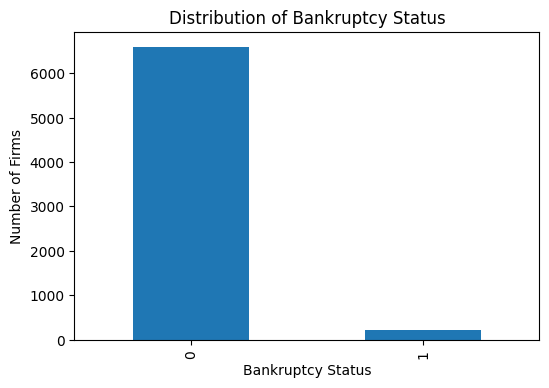

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

df["Bankrupt?"].value_counts().plot(
    kind="bar"
)

plt.title("Distribution of Bankruptcy Status")
plt.xlabel("Bankruptcy Status")
plt.ylabel("Number of Firms")

plt.show()

## Correlation Analysis

Correlation analysis identifies relationships among financial indicators and helps detect variables that may contribute to bankruptcy prediction.

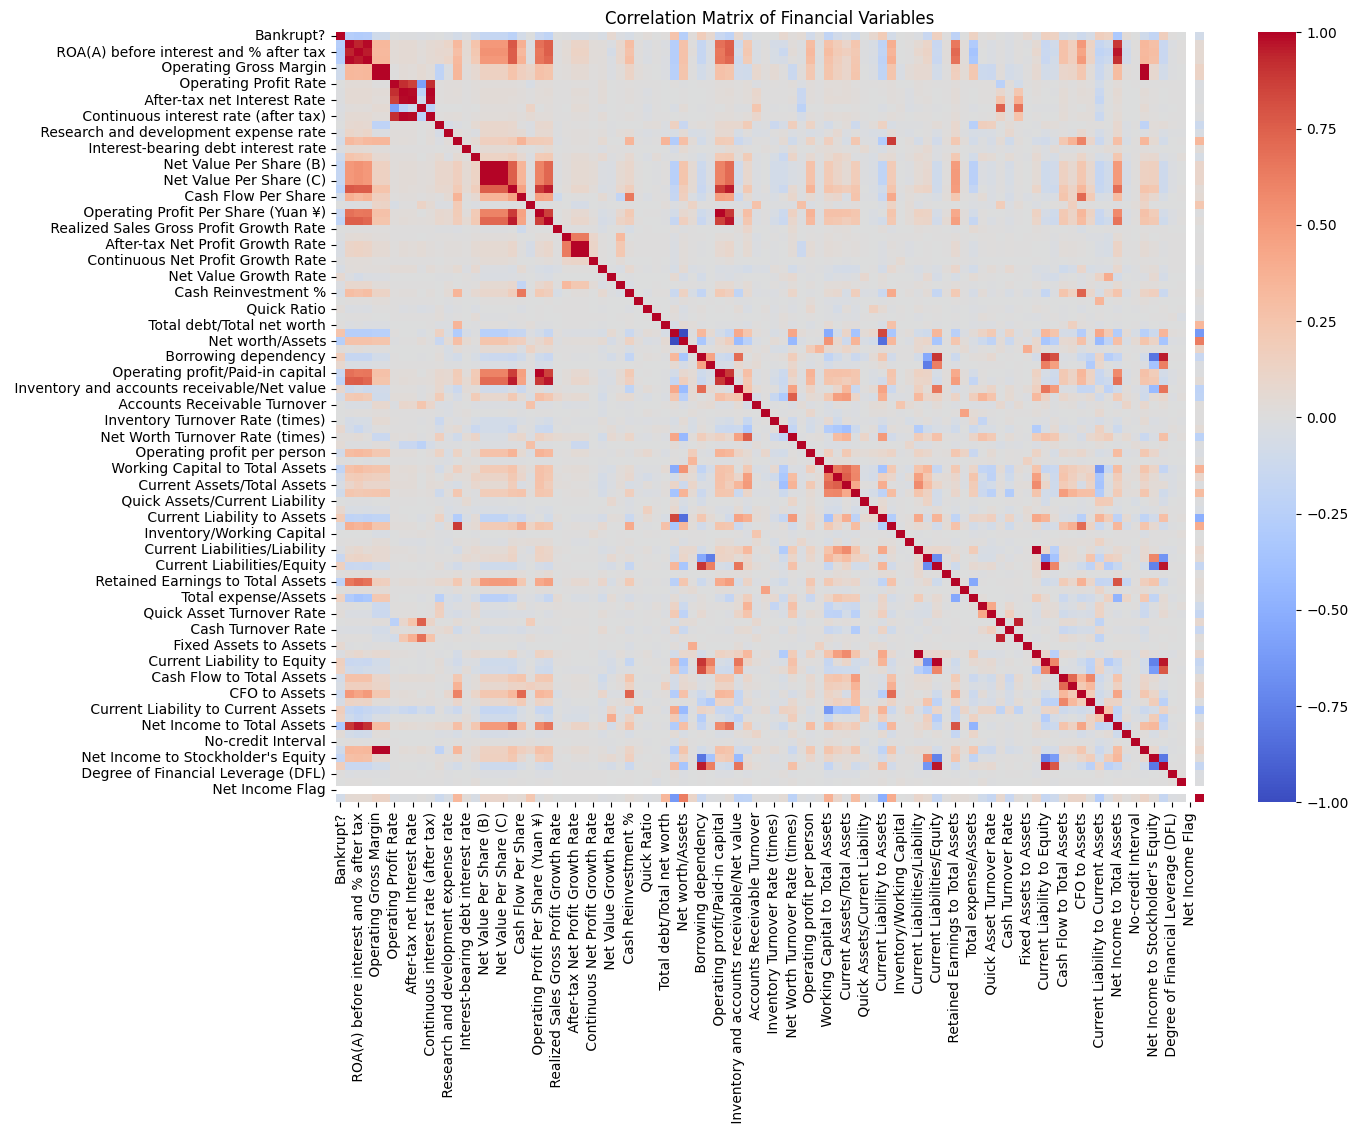

In [6]:
import seaborn as sns

plt.figure(figsize=(14,10))

corr = df.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Financial Variables")

plt.show()

In [7]:
# Correlation with target variable

bankruptcy_corr = df.corr()["Bankrupt?"].sort_values()

bankruptcy_corr

,Bankrupt?
Net Income to Total Assets,-0.315457
ROA(A) before interest and % after tax,-0.282941
ROA(B) before interest and depreciation after tax,-0.273051
ROA(C) before interest and depreciation before interest,-0.260807
Net worth/Assets,-0.250161
...,...
Borrowing dependency,0.176543
Current Liability to Assets,0.194494
Debt ratio %,0.250161
Bankrupt?,1.000000


## Key Exploratory Findings

The exploratory analysis identifies important characteristics of corporate financial risk.

Major observations include:

- The dataset contains multiple financial indicators related to profitability, liquidity, leverage, and operational performance.
- Bankruptcy outcomes show potential class imbalance.
- Several financial ratios demonstrate meaningful relationships with bankruptcy risk.
- These findings guide feature selection and predictive modeling in subsequent stages.

In [9]:
# Load processed financial dataset

import pandas as pd

url = "https://raw.githubusercontent.com/muhammad-siddique-research/financial-risk-ai/8c741d8c5d68b091c93de825ad49eec88e156dd2/data/processed/financial_data_cleaned.csv"

df = pd.read_csv(url)

print("Processed dataset loaded successfully")

df.head()

Processed dataset loaded successfully


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [10]:
# Check dataset structure

print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape:
(6819, 96)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                               

In [11]:
# Check missing values

missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0


In [12]:
# Statistical summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Bankrupt?,6819.0,0.032263,0.176710,0.0,0.000000,0.000000,0.000000,1.0
ROA(C) before interest and depreciation before interest,6819.0,0.505180,0.060686,0.0,0.476527,0.502706,0.535563,1.0
ROA(A) before interest and % after tax,6819.0,0.558625,0.065620,0.0,0.535543,0.559802,0.589157,1.0
ROA(B) before interest and depreciation after tax,6819.0,0.553589,0.061595,0.0,0.527277,0.552278,0.584105,1.0
Operating Gross Margin,6819.0,0.607948,0.016934,0.0,0.600445,0.605997,0.613914,1.0
...,...,...,...,...,...,...,...,...
Liability to Equity,6819.0,0.280365,0.014463,0.0,0.276944,0.278778,0.281449,1.0
Degree of Financial Leverage (DFL),6819.0,0.027541,0.015668,0.0,0.026791,0.026808,0.026913,1.0
Interest Coverage Ratio (Interest expense to EBIT),6819.0,0.565358,0.013214,0.0,0.565158,0.565252,0.565725,1.0
Net Income Flag,6819.0,1.000000,0.000000,1.0,1.000000,1.000000,1.000000,1.0


Bankrupt?
0    6599
1     220
Name: count, dtype: int64


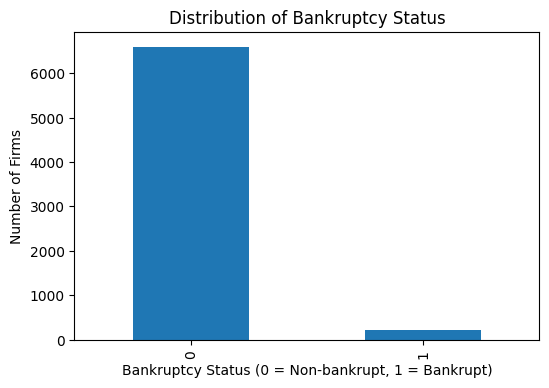

In [13]:
# Bankruptcy class distribution

bankruptcy_counts = df["Bankrupt?"].value_counts()

print(bankruptcy_counts)

# Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

bankruptcy_counts.plot(
    kind="bar",
    title="Distribution of Bankruptcy Status"
)

plt.xlabel("Bankruptcy Status (0 = Non-bankrupt, 1 = Bankrupt)")
plt.ylabel("Number of Firms")

plt.show()

In [14]:
# Correlation analysis with bankruptcy status

correlation = df.corr()["Bankrupt?"].sort_values(ascending=False)

correlation.head(15)

,Bankrupt?
Bankrupt?,1.000000
Debt ratio %,0.250161
Current Liability to Assets,0.194494
Borrowing dependency,0.176543
Current Liability to Current Assets,0.171306
Liability to Equity,0.166812
Current Liabilities/Equity,0.153828
Current Liability to Equity,0.153828
Liability-Assets Flag,0.139212
Total expense/Assets,0.139049


In [15]:
# Most negative correlations with bankruptcy

correlation.tail(15)

,Bankrupt?
Net Value Per Share (C),-0.164784
Net Value Per Share (B),-0.165399
Net Value Per Share (A),-0.165465
Net Income to Stockholder's Equity,-0.180987
Working Capital to Total Assets,-0.193083
Per Share Net profit before tax (Yuan ¥),-0.201395
Net profit before tax/Paid-in capital,-0.207857
Retained Earnings to Total Assets,-0.217779
Persistent EPS in the Last Four Seasons,-0.219560
Net worth/Assets,-0.250161


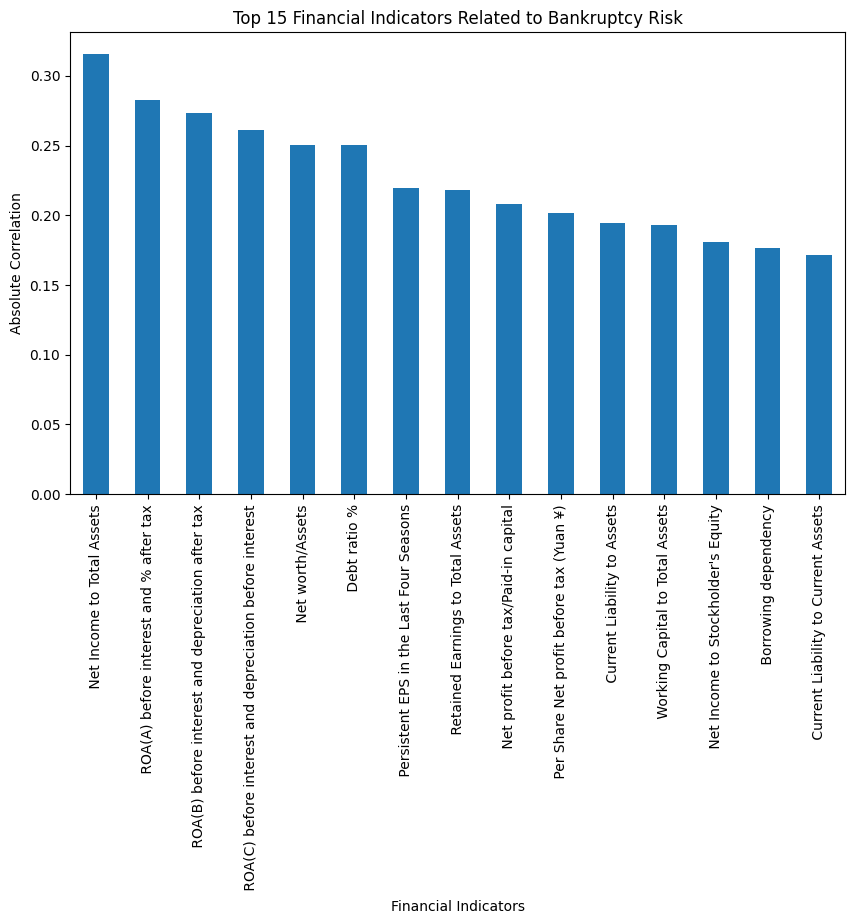

In [16]:
import matplotlib.pyplot as plt

top_features = correlation.drop("Bankrupt?").abs().sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))

top_features.plot(
    kind="bar",
    title="Top 15 Financial Indicators Related to Bankruptcy Risk"
)

plt.xlabel("Financial Indicators")
plt.ylabel("Absolute Correlation")

plt.xticks(rotation=90)

plt.show()

In [17]:
# Select important financial variables for distribution analysis

selected_features = [
    "ROA(C) before interest and depreciation before interest",
    "ROA(A) before interest and % after tax",
    "ROA(B) before interest and depreciation after tax",
    "Operating Gross Margin",
    "Cash flow rate",
    "Debt ratio %",
]

selected_features

['ROA(C) before interest and depreciation before interest',
 'ROA(A) before interest and % after tax',
 'ROA(B) before interest and depreciation after tax',
 'Operating Gross Margin',
 'Cash flow rate',
 'Debt ratio %']

In [21]:
# Remove extra spaces from column names

df.columns = df.columns.str.strip()

print("Column names cleaned successfully")

Column names cleaned successfully


In [22]:
for feature in selected_features:
    print(feature, "→", feature in df.columns)

ROA(C) before interest and depreciation before interest → True
ROA(A) before interest and % after tax → True
ROA(B) before interest and depreciation after tax → True
Operating Gross Margin → True
Cash flow rate → True
Debt ratio % → True


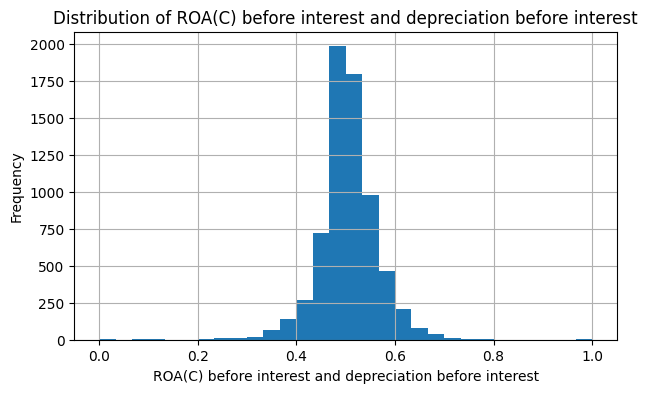

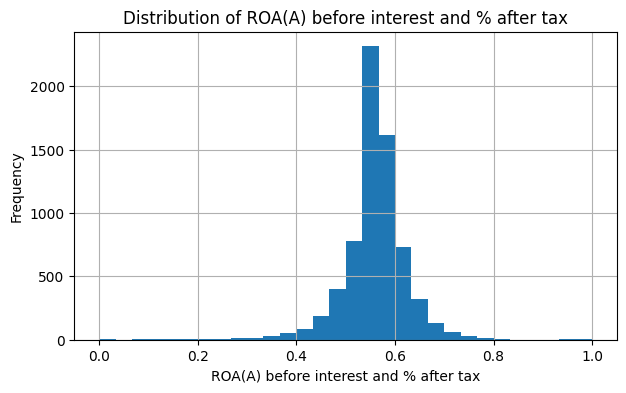

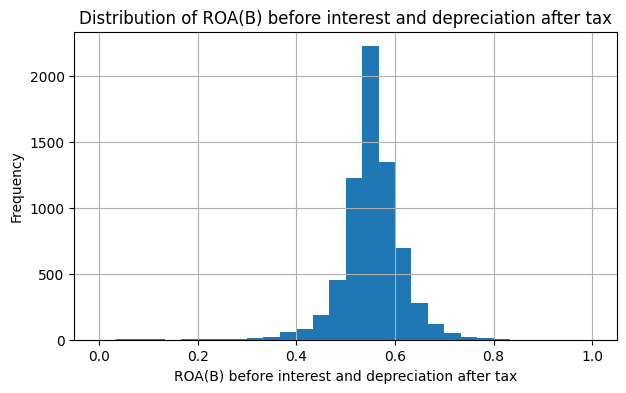

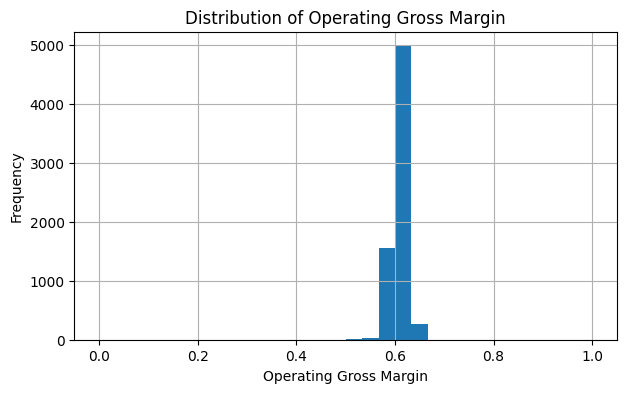

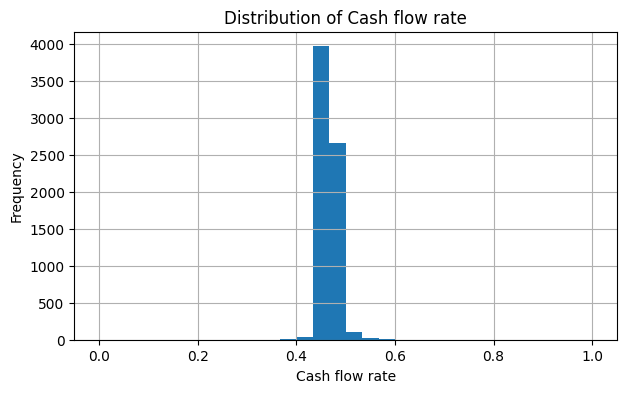

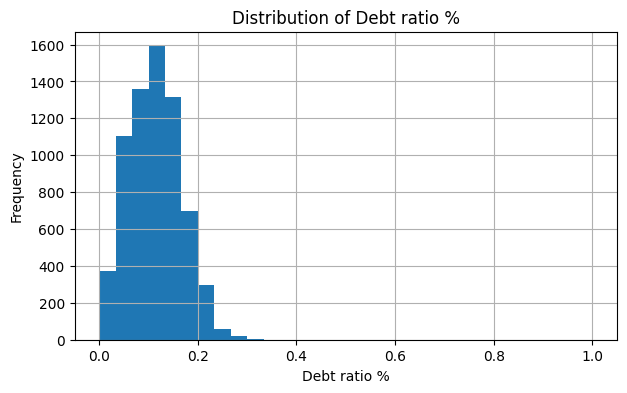

In [23]:
import matplotlib.pyplot as plt

for feature in selected_features:

    plt.figure(figsize=(7,4))

    df[feature].hist(bins=30)

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.show()

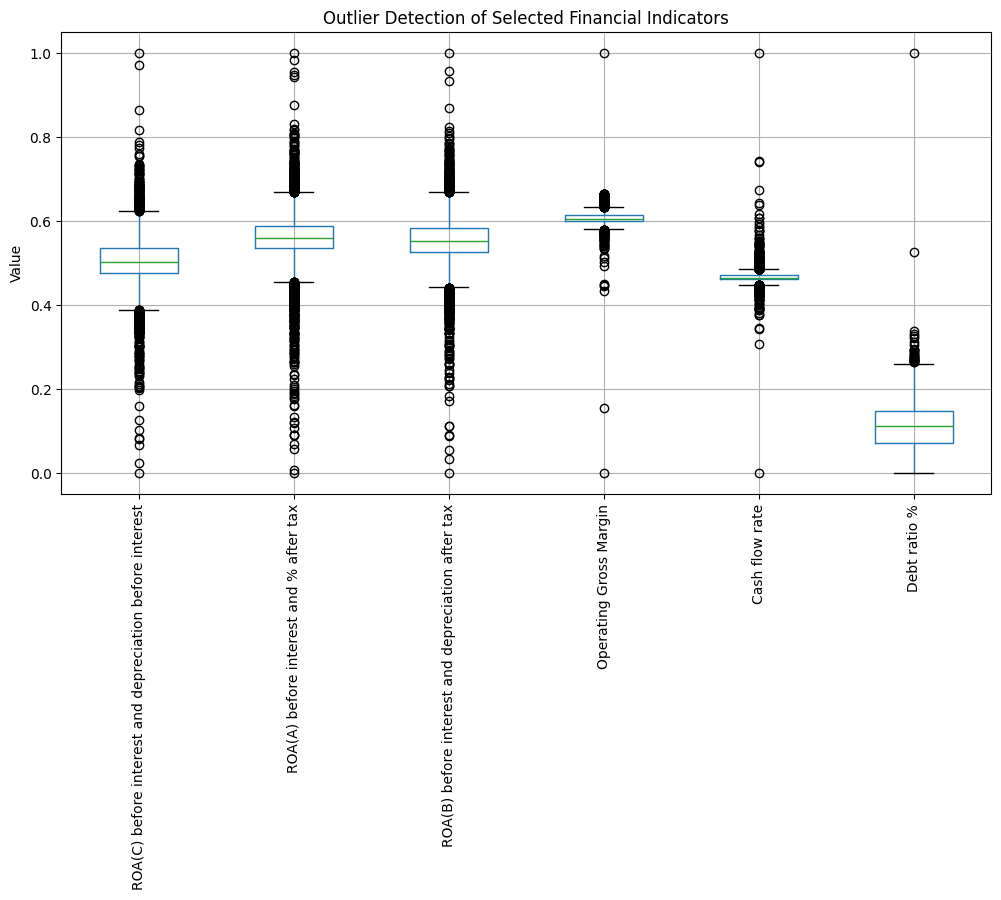

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

df[selected_features].boxplot(rot=90)

plt.title("Outlier Detection of Selected Financial Indicators")

plt.ylabel("Value")

plt.show()

In [25]:
# Compare financial indicators between bankrupt and non-bankrupt firms

group_comparison = df.groupby("Bankrupt?")[selected_features].mean()

group_comparison

,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Cash flow rate,Debt ratio %
Bankrupt?,,,,,,
0,0.508069,0.562015,0.556659,0.608257,0.467656,0.110714
1,0.418503,0.456947,0.461483,0.598670,0.460681,0.187047


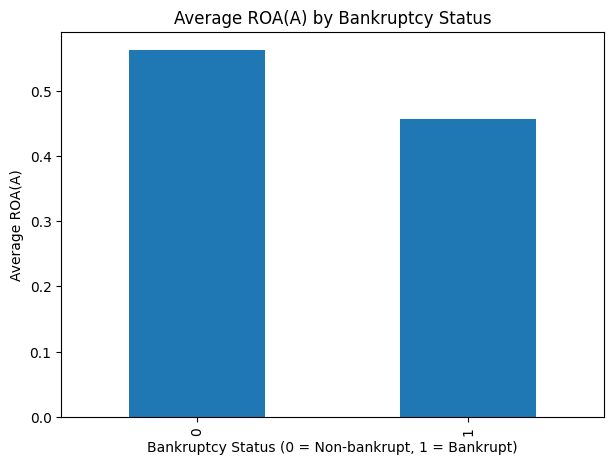

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

df.groupby("Bankrupt?")["ROA(A) before interest and % after tax"].mean().plot(
    kind="bar"
)

plt.title("Average ROA(A) by Bankruptcy Status")

plt.xlabel("Bankruptcy Status (0 = Non-bankrupt, 1 = Bankrupt)")

plt.ylabel("Average ROA(A)")

plt.show()

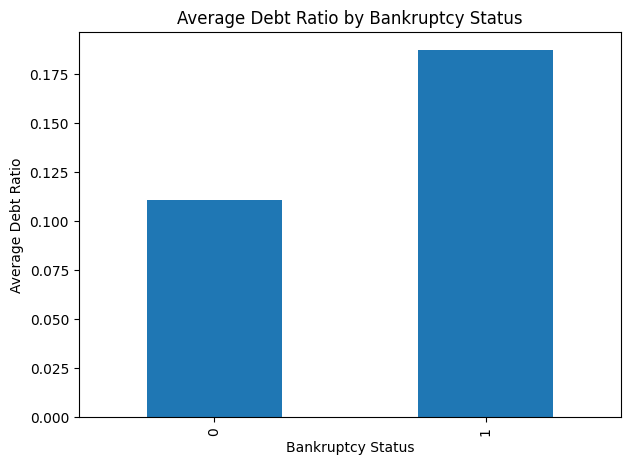

In [27]:
plt.figure(figsize=(7,5))

df.groupby("Bankrupt?")["Debt ratio %"].mean().plot(
    kind="bar"
)

plt.title("Average Debt Ratio by Bankruptcy Status")

plt.xlabel("Bankruptcy Status")

plt.ylabel("Average Debt Ratio")

plt.show()

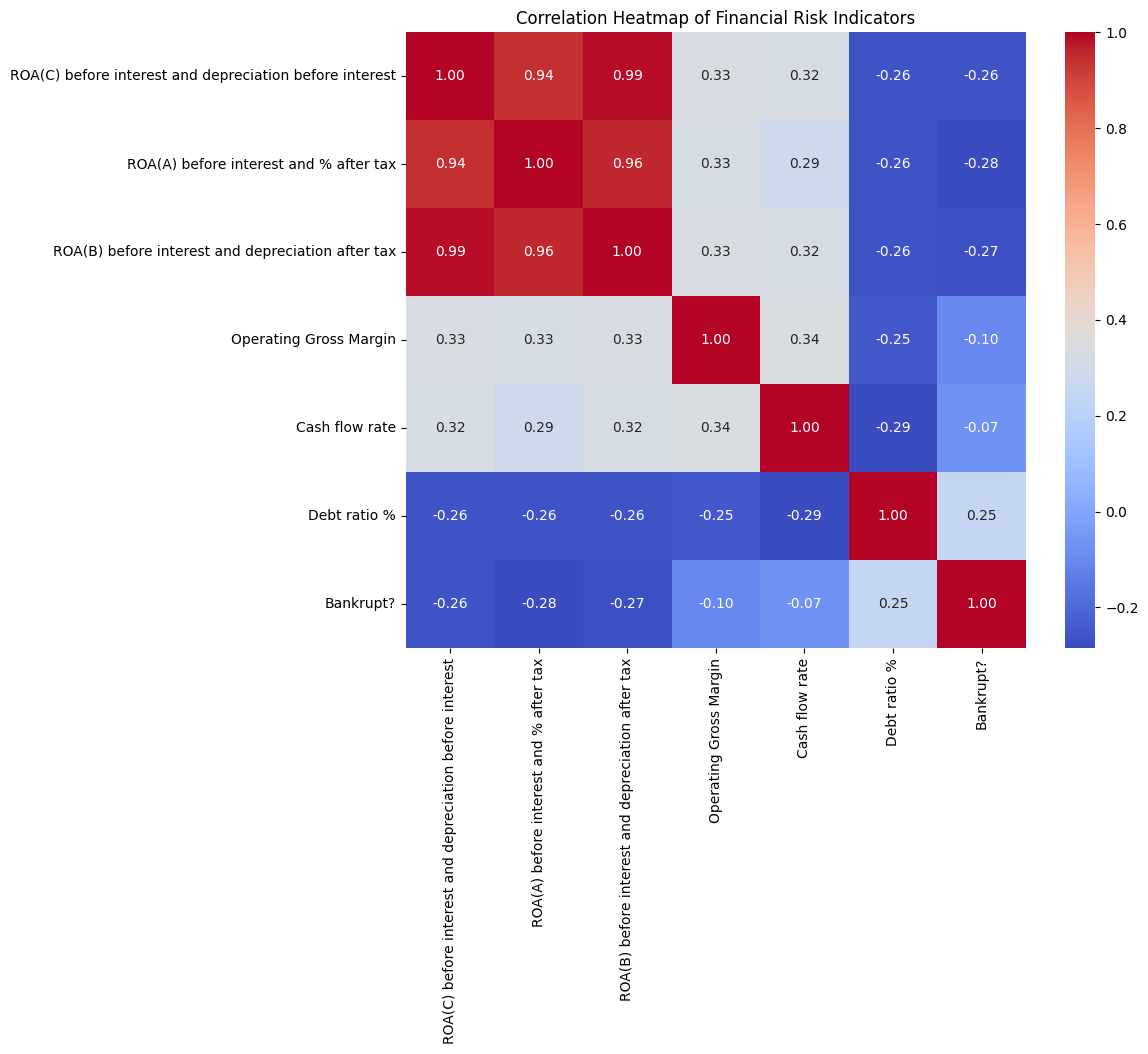

In [28]:
# Correlation heatmap of selected financial indicators

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

correlation_matrix = df[selected_features + ["Bankrupt?"]].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Financial Risk Indicators")

plt.show()

### Observation

The correlation analysis indicates that profitability indicators (ROA measures) are negatively associated with bankruptcy status, while debt ratio shows a positive association. Strong correlations among ROA variables suggest potential multicollinearity, which will be considered during feature engineering and model development.

In [29]:
# Save EDA summary tables

import os

os.makedirs("../results", exist_ok=True)

# Descriptive statistics
df.describe().T.to_csv("../results/descriptive_statistics.csv")

# Correlation matrix
df.corr().to_csv("../results/correlation_matrix.csv")

print("EDA results saved successfully")

EDA results saved successfully


In [30]:
# Create results folder for EDA outputs

import os

os.makedirs("../results", exist_ok=True)

print("Results folder created successfully")

Results folder created successfully


In [31]:
# Save descriptive statistics

df.describe().T.to_csv("../results/descriptive_statistics.csv")

# Save correlation matrix

df.corr().to_csv("../results/correlation_matrix.csv")

print("EDA results saved successfully")

EDA results saved successfully


In [47]:
!find /content -name "*.csv"

/content/sample_data/california_housing_test.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_test.csv
/content/sample_data/mnist_train_small.csv


In [48]:
df.shape

(6819, 96)

In [49]:
import os

os.makedirs("/content/data/processed", exist_ok=True)

df.to_csv(
    "/content/data/processed/financial_data_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully


In [50]:
os.path.exists("/content/data/processed/financial_data_cleaned.csv")

True

In [51]:
from google.colab import files

files.download("/content/data/processed/financial_data_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [52]:
import pandas as pd

url = "https://raw.githubusercontent.com/muhammad-siddique-research/financial-risk-ai/main/data/processed/financial_data_cleaned.csv"

df = pd.read_csv(url)

print("Processed dataset loaded successfully")

df.head()

Processed dataset loaded successfully


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


Dataset Shape:
(6819, 96)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                               

In [57]:
Bankrupt?

Object `Bankrupt` not found.


Bankrupt?
0    6599
1     220
Name: count, dtype: int64

Percentage Distribution:
Bankrupt?
0    96.77372
1     3.22628
Name: proportion, dtype: float64


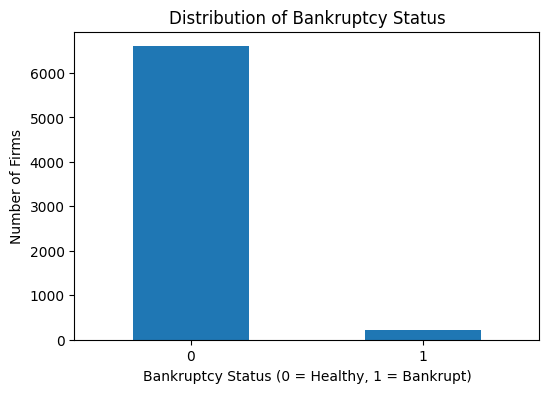

In [58]:
# Analyze target variable distribution

import matplotlib.pyplot as plt

# Count classes
bankruptcy_counts = df["Bankrupt?"].value_counts()

print(bankruptcy_counts)

# Percentage distribution
print("\nPercentage Distribution:")
print(df["Bankrupt?"].value_counts(normalize=True) * 100)

# Visualization

plt.figure(figsize=(6,4))

bankruptcy_counts.plot(
    kind="bar"
)

plt.title("Distribution of Bankruptcy Status")
plt.xlabel("Bankruptcy Status (0 = Healthy, 1 = Bankrupt)")
plt.ylabel("Number of Firms")

plt.xticks(rotation=0)

plt.show()

In [59]:
df.columns.tolist()

['Bankrupt?',
 ' ROA(C) before interest and depreciation before interest',
 ' ROA(A) before interest and % after tax',
 ' ROA(B) before interest and depreciation after tax',
 ' Operating Gross Margin',
 ' Realized Sales Gross Margin',
 ' Operating Profit Rate',
 ' Pre-tax net Interest Rate',
 ' After-tax net Interest Rate',
 ' Non-industry income and expenditure/revenue',
 ' Continuous interest rate (after tax)',
 ' Operating Expense Rate',
 ' Research and development expense rate',
 ' Cash flow rate',
 ' Interest-bearing debt interest rate',
 ' Tax rate (A)',
 ' Net Value Per Share (B)',
 ' Net Value Per Share (A)',
 ' Net Value Per Share (C)',
 ' Persistent EPS in the Last Four Seasons',
 ' Cash Flow Per Share',
 ' Revenue Per Share (Yuan ¥)',
 ' Operating Profit Per Share (Yuan ¥)',
 ' Per Share Net profit before tax (Yuan ¥)',
 ' Realized Sales Gross Profit Growth Rate',
 ' Operating Profit Growth Rate',
 ' After-tax Net Profit Growth Rate',
 ' Regular Net Profit Growth Rate',
 ' C

In [60]:
for col in df.columns:
    if "ROA" in col or "Cash" in col or "Debt" in col or "Gross Margin" in col:
        print(col)

 ROA(C) before interest and depreciation before interest
 ROA(A) before interest and % after tax
 ROA(B) before interest and depreciation after tax
 Operating Gross Margin
 Realized Sales Gross Margin
 Cash flow rate
 Cash Flow Per Share
 Cash Reinvestment %
 Debt ratio %
 Cash/Total Assets
 Cash/Current Liability
 Cash Turnover Rate
 Cash Flow to Sales
 Cash Flow to Total Assets
 Cash Flow to Liability
 Cash Flow to Equity


In [61]:
for col in df.columns:
    print(repr(col))

'Bankrupt?'
' ROA(C) before interest and depreciation before interest'
' ROA(A) before interest and % after tax'
' ROA(B) before interest and depreciation after tax'
' Operating Gross Margin'
' Realized Sales Gross Margin'
' Operating Profit Rate'
' Pre-tax net Interest Rate'
' After-tax net Interest Rate'
' Non-industry income and expenditure/revenue'
' Continuous interest rate (after tax)'
' Operating Expense Rate'
' Research and development expense rate'
' Cash flow rate'
' Interest-bearing debt interest rate'
' Tax rate (A)'
' Net Value Per Share (B)'
' Net Value Per Share (A)'
' Net Value Per Share (C)'
' Persistent EPS in the Last Four Seasons'
' Cash Flow Per Share'
' Revenue Per Share (Yuan ¥)'
' Operating Profit Per Share (Yuan ¥)'
' Per Share Net profit before tax (Yuan ¥)'
' Realized Sales Gross Profit Growth Rate'
' Operating Profit Growth Rate'
' After-tax Net Profit Growth Rate'
' Regular Net Profit Growth Rate'
' Continuous Net Profit Growth Rate'
' Total Asset Growth Ra

In [62]:
for col in df.columns:
    if "ROA" in col or "Cash" in col or "Debt" in col or "Gross Margin" in col:
        print(repr(col))

' ROA(C) before interest and depreciation before interest'
' ROA(A) before interest and % after tax'
' ROA(B) before interest and depreciation after tax'
' Operating Gross Margin'
' Realized Sales Gross Margin'
' Cash flow rate'
' Cash Flow Per Share'
' Cash Reinvestment %'
' Debt ratio %'
' Cash/Total Assets'
' Cash/Current Liability'
' Cash Turnover Rate'
' Cash Flow to Sales'
' Cash Flow to Total Assets'
' Cash Flow to Liability'
' Cash Flow to Equity'


In [64]:
# Remove hidden spaces from column names

df.columns = df.columns.str.strip()

print("Column names cleaned")

Column names cleaned


In [65]:
for col in df.columns:
    if "ROA" in col:
        print(repr(col))

'ROA(C) before interest and depreciation before interest'
'ROA(A) before interest and % after tax'
'ROA(B) before interest and depreciation after tax'


In [66]:
selected_features = [
    col for col in df.columns
    if "ROA" in col or
       "Operating Gross Margin" in col or
       "Cash flow rate" in col
]

print(selected_features)

['ROA(C) before interest and depreciation before interest', 'ROA(A) before interest and % after tax', 'ROA(B) before interest and depreciation after tax', 'Operating Gross Margin', 'Cash flow rate']


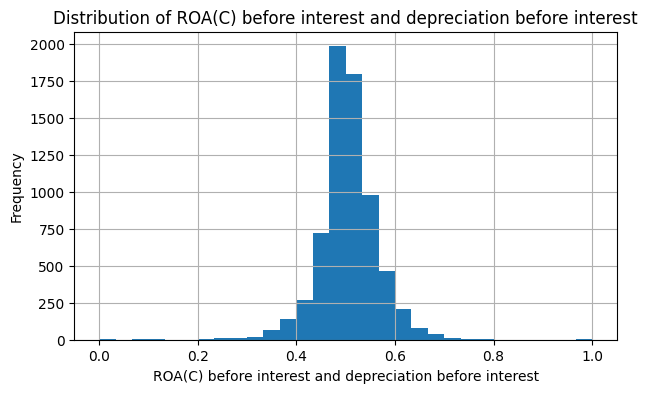

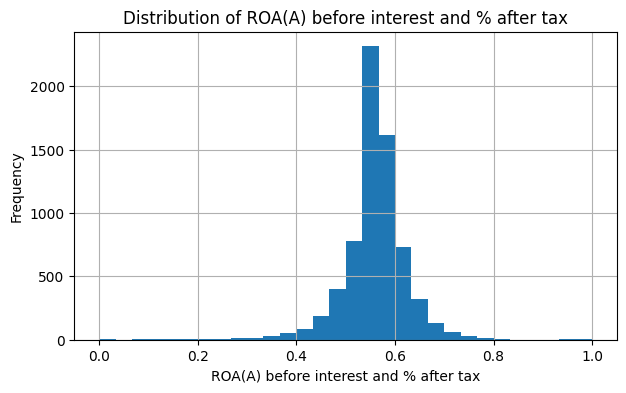

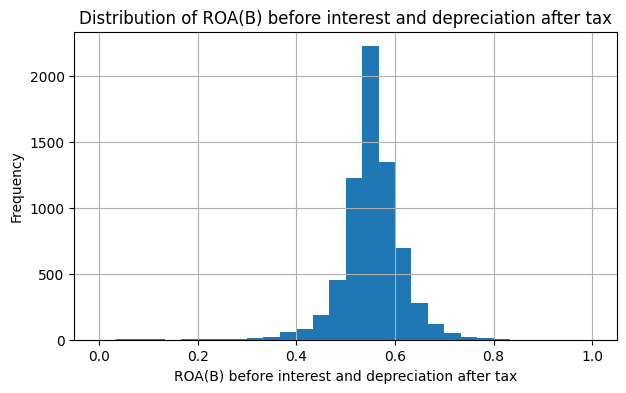

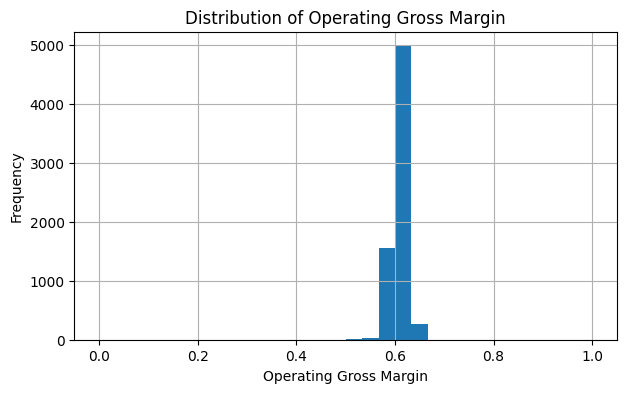

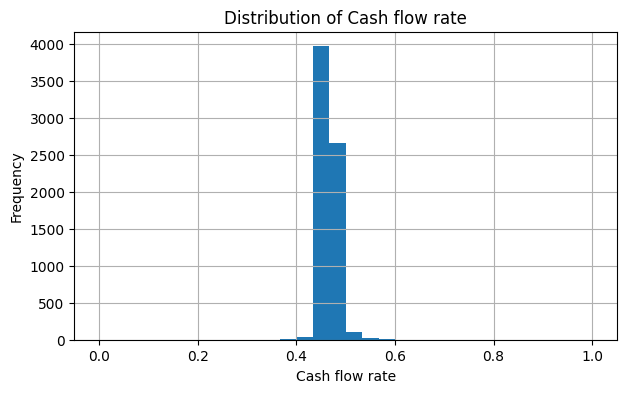

In [67]:
import matplotlib.pyplot as plt

for feature in selected_features:

    plt.figure(figsize=(7,4))

    df[feature].hist(bins=30)

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.show()

In [68]:
# Compare financial indicators by bankruptcy status

comparison_features = [
    "ROA(C) before interest and depreciation before interest",
    "ROA(A) before interest and % after tax",
    "ROA(B) before interest and depreciation after tax",
    "Operating Gross Margin",
    "Cash flow rate"
]


for feature in comparison_features:

    comparison = df.groupby("Bankrupt?")[feature].mean()

    print("\n", feature)
    print(comparison)


 ROA(C) before interest and depreciation before interest
Bankrupt?
0    0.508069
1    0.418503
Name: ROA(C) before interest and depreciation before interest, dtype: float64

 ROA(A) before interest and % after tax
Bankrupt?
0    0.562015
1    0.456947
Name: ROA(A) before interest and % after tax, dtype: float64

 ROA(B) before interest and depreciation after tax
Bankrupt?
0    0.556659
1    0.461483
Name: ROA(B) before interest and depreciation after tax, dtype: float64

 Operating Gross Margin
Bankrupt?
0    0.608257
1    0.598670
Name: Operating Gross Margin, dtype: float64

 Cash flow rate
Bankrupt?
0    0.467656
1    0.460681
Name: Cash flow rate, dtype: float64


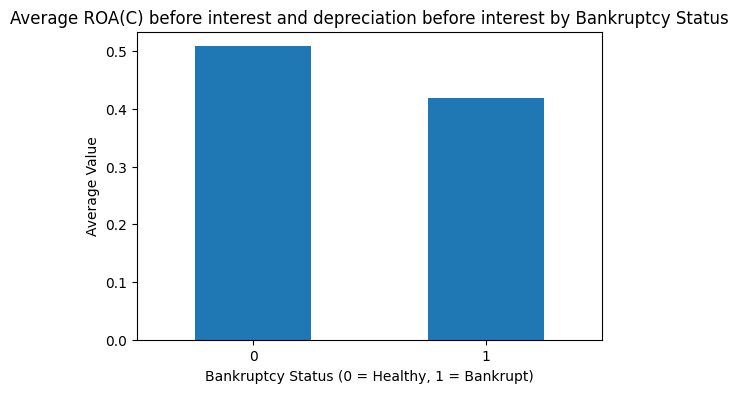

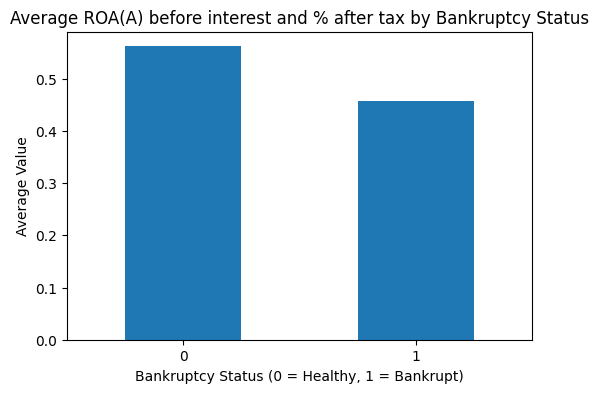

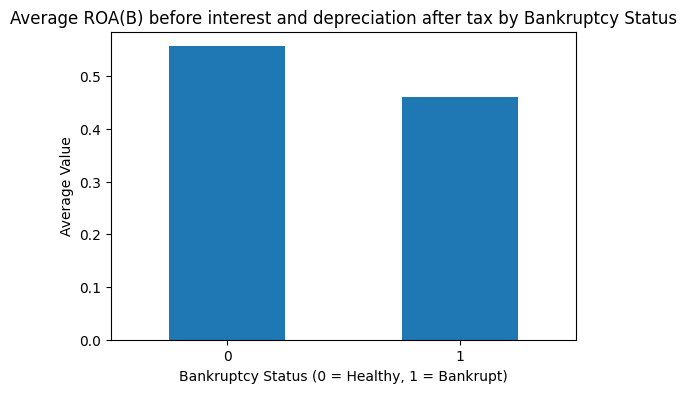

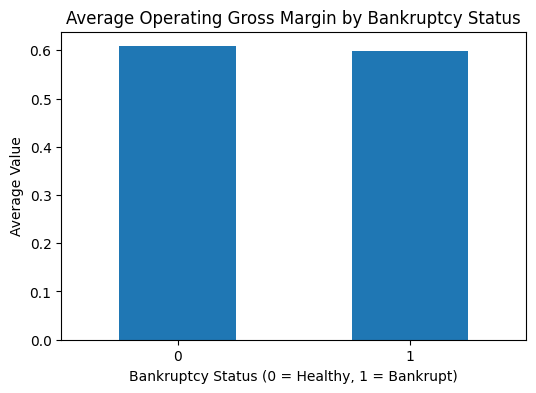

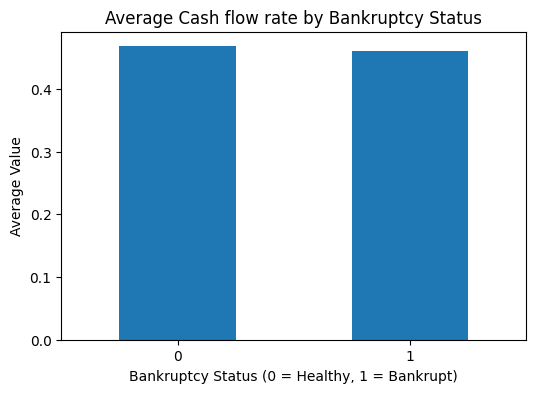

In [69]:
import matplotlib.pyplot as plt

comparison_features = [
    "ROA(C) before interest and depreciation before interest",
    "ROA(A) before interest and % after tax",
    "ROA(B) before interest and depreciation after tax",
    "Operating Gross Margin",
    "Cash flow rate"
]


for feature in comparison_features:

    comparison = df.groupby("Bankrupt?")[feature].mean()

    plt.figure(figsize=(6,4))

    comparison.plot(
        kind="bar"
    )

    plt.title(f"Average {feature} by Bankruptcy Status")
    plt.xlabel("Bankruptcy Status (0 = Healthy, 1 = Bankrupt)")
    plt.ylabel("Average Value")

    plt.xticks(rotation=0)

    plt.show()

In [70]:
# Correlation of financial indicators with bankruptcy

correlation = df.corr()["Bankrupt?"].sort_values()

correlation.head(10)

,Bankrupt?
Net Income to Total Assets,-0.315457
ROA(A) before interest and % after tax,-0.282941
ROA(B) before interest and depreciation after tax,-0.273051
ROA(C) before interest and depreciation before interest,-0.260807
Net worth/Assets,-0.250161
Persistent EPS in the Last Four Seasons,-0.219560
Retained Earnings to Total Assets,-0.217779
Net profit before tax/Paid-in capital,-0.207857
Per Share Net profit before tax (Yuan ¥),-0.201395
Working Capital to Total Assets,-0.193083


In [71]:
correlation.tail(10)

,Bankrupt?
Liability-Assets Flag,0.139212
Current Liabilities/Equity,0.153828
Current Liability to Equity,0.153828
Liability to Equity,0.166812
Current Liability to Current Assets,0.171306
Borrowing dependency,0.176543
Current Liability to Assets,0.194494
Debt ratio %,0.250161
Bankrupt?,1.000000
Net Income Flag,NaN


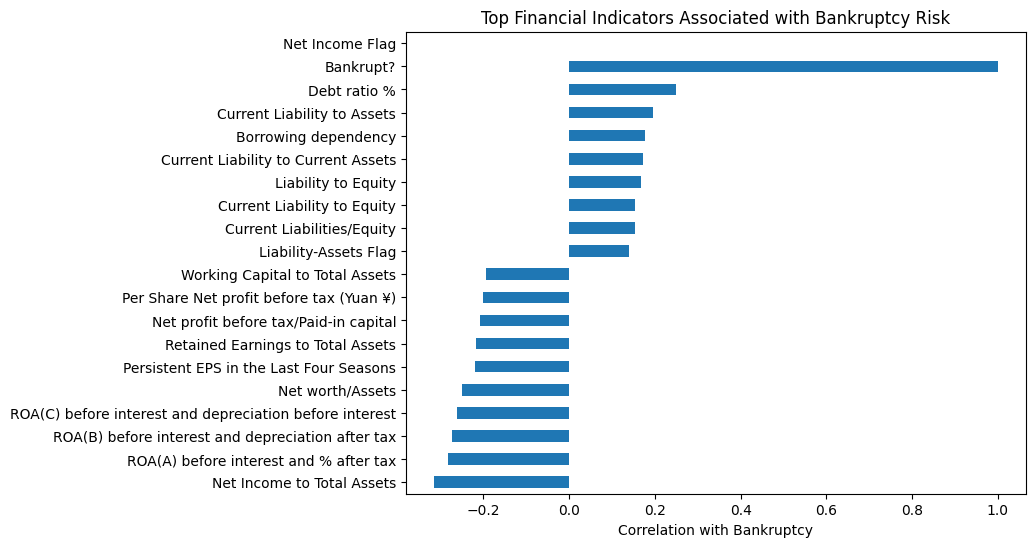

In [72]:
import matplotlib.pyplot as plt

top_corr = pd.concat([
    correlation.head(10),
    correlation.tail(10)
])


plt.figure(figsize=(8,6))

top_corr.plot(
    kind="barh"
)

plt.title("Top Financial Indicators Associated with Bankruptcy Risk")
plt.xlabel("Correlation with Bankruptcy")

plt.show()

<Figure size 700x400 with 0 Axes>

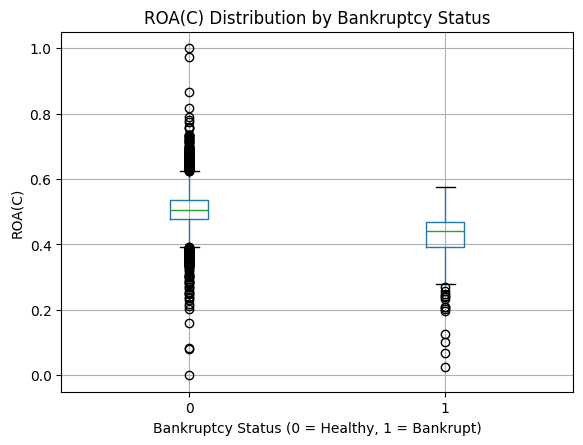

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

df.boxplot(
    column="ROA(C) before interest and depreciation before interest",
    by="Bankrupt?"
)

plt.title("ROA(C) Distribution by Bankruptcy Status")
plt.suptitle("")

plt.xlabel("Bankruptcy Status (0 = Healthy, 1 = Bankrupt)")
plt.ylabel("ROA(C)")

plt.show()

<Figure size 700x400 with 0 Axes>

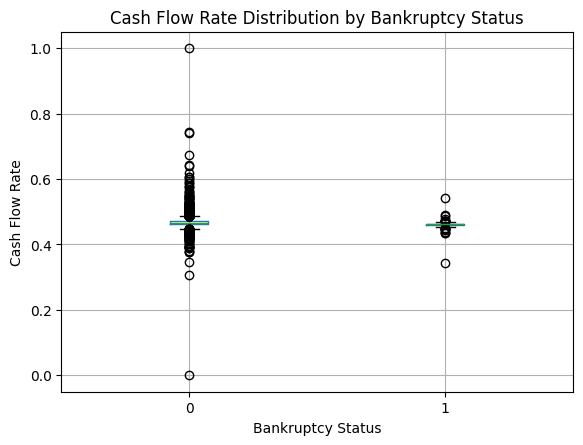

In [74]:
plt.figure(figsize=(7,4))

df.boxplot(
    column="Cash flow rate",
    by="Bankrupt?"
)

plt.title("Cash Flow Rate Distribution by Bankruptcy Status")
plt.suptitle("")

plt.xlabel("Bankruptcy Status")
plt.ylabel("Cash Flow Rate")

plt.show()

In [75]:
for col in df.columns:
    if "Debt" in col or "debt" in col:
        print(col)

Interest-bearing debt interest rate
Total debt/Total net worth
Debt ratio %


# Key Findings from Exploratory Data Analysis

The exploratory analysis provided several important insights into the relationship between corporate financial indicators and bankruptcy risk.

## Profitability Indicators

The analysis shows that profitability-related indicators, including ROA measures, are generally lower among bankrupt firms compared with healthy firms. This suggests that weaker asset utilization and lower returns are associated with increased financial distress.

## Operating Performance

Operating Gross Margin and related performance indicators demonstrate differences between healthy and bankrupt firms, indicating that operational efficiency plays an important role in financial stability.

## Cash Flow Position

Cash flow indicators show variation between bankruptcy groups, highlighting the importance of liquidity generation and internal financing capacity in predicting financial risk.

## Financial Risk Indicators

Correlation analysis identified several financial ratios that have meaningful relationships with bankruptcy status. These indicators provide potential predictive signals for later econometric and machine learning models.

## Implications for Modeling

The findings from exploratory analysis support the development of predictive models using financial indicators. The selected variables will be further processed through feature engineering before applying econometric and machine learning approaches.